Device: cpu

PRE-TRAINING: Base model with 4 cardinal actions
[Naive] Ep 20: Reward=-383, Avg=-355, Success=5%, Eps=0.905
[Naive] Ep 40: Reward=-23, Avg=-155, Success=80%, Eps=0.818
[Naive] Ep 60: Reward=4, Avg=-86, Success=90%, Eps=0.740
[Naive] Ep 80: Reward=-52, Avg=-45, Success=100%, Eps=0.670
[Naive] Ep 100: Reward=29, Avg=-21, Success=100%, Eps=0.606
[Naive] Ep 120: Reward=-25, Avg=-4, Success=100%, Eps=0.548
[Naive] Ep 140: Reward=27, Avg=11, Success=100%, Eps=0.496
[Naive] Ep 160: Reward=41, Avg=16, Success=100%, Eps=0.448
[Naive] Ep 180: Reward=44, Avg=26, Success=100%, Eps=0.406
[Naive] Ep 200: Reward=12, Avg=33, Success=100%, Eps=0.367

Base model saved. Final: Reward=33, Success=100%

COMPARISON: Naive vs Original (8 actions)

[1] NAIVE - Training from scratch...
[Naive] Ep 20: Reward=-382, Avg=-336, Success=20%, Eps=0.905
[Naive] Ep 40: Reward=39, Avg=-134, Success=85%, Eps=0.818
[Naive] Ep 60: Reward=9, Avg=-60, Success=100%, Eps=0.740
[Naive] Ep 80: Reward=-12, Avg=1, Su

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_95670/2021915852.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_dict = torch.load(base_model_path, map

[Original] Ep 20: Reward=41, Avg=19, Success=100%, Reuse=105, Reject=415
[Original] Ep 40: Reward=57, Avg=37, Success=100%, Reuse=299, Reject=688
[Original] Ep 60: Reward=33, Avg=39, Success=100%, Reuse=525, Reject=938
[Original] Ep 80: Reward=50, Avg=49, Success=100%, Reuse=771, Reject=1119
[Original] Ep 100: Reward=47, Avg=43, Success=100%, Reuse=1095, Reject=1300
[Original] Ep 120: Reward=65, Avg=59, Success=100%, Reuse=1359, Reject=1431
[Original] Ep 140: Reward=61, Avg=58, Success=100%, Reuse=1632, Reject=1555
[Original] Ep 160: Reward=54, Avg=59, Success=100%, Reuse=1938, Reject=1657
[Original] Ep 180: Reward=63, Avg=60, Success=100%, Reuse=2252, Reject=1735
[Original] Ep 200: Reward=64, Avg=61, Success=100%, Reuse=2578, Reject=1814


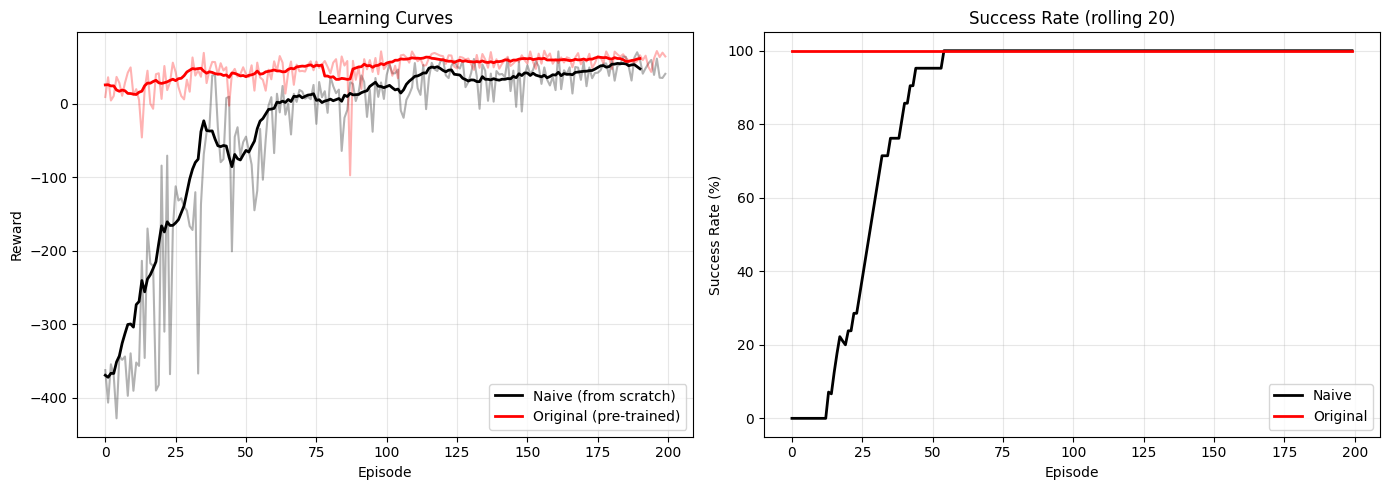


SUMMARY
Base (4 actions):  Reward=33, Success=100%
Naive (8 actions): Reward=51, Success=100%
Original:          Reward=61, Success=100%
                   Reuse=2578, Reject=1814

Sample Efficiency (AUC):
  Naive:    -6440
  Original: 9677
  Improvement: 250.3%


In [4]:
"""
Continuous GridWorld: Original vs Naive Comparison
===================================================

Focus on making Original method beat Naive.

Key insight from results:
- Original has FASTER early learning (pre-trained features help)
- But Naive catches up eventually

Goal: Understand why and make Original maintain advantage.
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


# =============================================================================
# Continuous GridWorld Environment
# =============================================================================

class ContinuousGridWorld(gym.Env):
    """
    Continuous GridWorld: State is (x, y) in [0,1] x [0,1]
    Goal: Reach (0.9, 0.9)
    """
    
    def __init__(self, n_actions=8, step_size=0.05, goal_radius=0.1, max_steps=200):
        super().__init__()
        
        self.step_size = step_size
        self.goal_radius = goal_radius
        self.max_steps = max_steps
        self.goal = np.array([0.9, 0.9])
        
        self.observation_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Discrete(n_actions)
        
        # Actions: 0-3 cardinal, 4-7 diagonal
        self.directions = {
            0: np.array([0, 1]),     # Up
            1: np.array([0, -1]),    # Down
            2: np.array([-1, 0]),    # Left
            3: np.array([1, 0]),     # Right
            4: np.array([-1, 1]) / np.sqrt(2),   # Up-Left
            5: np.array([1, 1]) / np.sqrt(2),    # Up-Right
            6: np.array([-1, -1]) / np.sqrt(2),  # Down-Left
            7: np.array([1, -1]) / np.sqrt(2),   # Down-Right
        }
        
        self.state = None
        self.steps = 0
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([np.random.uniform(0.05, 0.3), np.random.uniform(0.05, 0.3)], dtype=np.float32)
        self.steps = 0
        return self.state.copy(), {}
    
    def step(self, action):
        direction = self.directions[action]
        self.state = np.clip(self.state + direction * self.step_size, 0, 1).astype(np.float32)
        self.steps += 1
        
        dist = np.linalg.norm(self.state - self.goal)
        reached = dist < self.goal_radius
        
        reward = 100.0 if reached else -1.0 - dist
        terminated = reached
        truncated = self.steps >= self.max_steps
        
        return self.state.copy(), reward, terminated, truncated, {}


# =============================================================================
# DQN Network
# =============================================================================

class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


# =============================================================================
# Naive Agent (train from scratch with 8 actions)
# =============================================================================

class NaiveAgent:
    def __init__(self, state_size, n_actions):
        self.n_actions = n_actions
        self.memory = deque(maxlen=50000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.lr = 0.001
        self.target_update = 500
        self.min_replay = 500
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = DQN(state_size, n_actions).to(self.device)
        self.target = DQN(state_size, n_actions).to(self.device)
        self.target.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.steps = 0

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            q = self.model(torch.FloatTensor(state).to(self.device))
        return q.argmax().item()

    def train_step(self):
        if len(self.memory) < self.min_replay:
            return
        batch = np.random.choice(len(self.memory), self.batch_size, replace=False)
        s = torch.FloatTensor([self.memory[i][0] for i in batch]).to(self.device)
        a = torch.LongTensor([self.memory[i][1] for i in batch]).to(self.device)
        r = torch.FloatTensor([self.memory[i][2] for i in batch]).to(self.device)
        ns = torch.FloatTensor([self.memory[i][3] for i in batch]).to(self.device)
        d = torch.FloatTensor([self.memory[i][4] for i in batch]).to(self.device)
        
        with torch.no_grad():
            target_q = r + self.gamma * self.target(ns).max(1)[0] * (1 - d)
        current_q = self.model(s).gather(1, a.unsqueeze(1)).squeeze()
        
        loss = F.smooth_l1_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

    def train(self, env, episodes=200):
        returns, successes = [], []
        for ep in range(episodes):
            state, _ = env.reset()
            total_reward, done, success = 0, False, False
            
            while not done:
                action = self.act(state)
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                success = term and reward > 50
                
                self.memory.append((state, action, reward, next_state, float(done)))
                self.train_step()
                self.steps += 1
                
                if self.steps % self.target_update == 0:
                    self.target.load_state_dict(self.model.state_dict())
                
                state = next_state
                total_reward += reward
            
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            returns.append(total_reward)
            successes.append(success)
            
            if (ep + 1) % 20 == 0:
                print(f"[Naive] Ep {ep+1}: Reward={total_reward:.0f}, Avg={np.mean(returns[-20:]):.0f}, "
                      f"Success={np.mean(successes[-20:])*100:.0f}%, Eps={self.epsilon:.3f}")
        
        return returns, successes


# =============================================================================
# Original Agent (pre-trained + expand with value filter)
# =============================================================================

class OriginalAgent:
    def __init__(self, state_size, n_actions, pretrained_model):
        self.n_actions = n_actions
        self.base_actions = [0, 1, 2, 3]
        self.new_actions = [4, 5, 6, 7]
        
        self.memory = deque(maxlen=50000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = 64
        self.lr = 0.001
        self.target_update = 500
        self.min_replay = 500
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = pretrained_model.to(self.device)
        self.target = DQN(state_size, n_actions).to(self.device)
        self.target.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.steps = 0
        
        # Stats
        self.reuse = 0
        self.reject = 0

    def act(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            q = self.model(torch.FloatTensor(state).to(self.device))
        return q.argmax().item()

    def train_step(self):
        if len(self.memory) < self.min_replay:
            return
        batch = np.random.choice(len(self.memory), self.batch_size, replace=False)
        s = torch.FloatTensor([self.memory[i][0] for i in batch]).to(self.device)
        a = torch.LongTensor([self.memory[i][1] for i in batch]).to(self.device)
        r = torch.FloatTensor([self.memory[i][2] for i in batch]).to(self.device)
        ns = torch.FloatTensor([self.memory[i][3] for i in batch]).to(self.device)
        d = torch.FloatTensor([self.memory[i][4] for i in batch]).to(self.device)
        
        with torch.no_grad():
            target_q = r + self.gamma * self.target(ns).max(1)[0] * (1 - d)
        current_q = self.model(s).gather(1, a.unsqueeze(1)).squeeze()
        
        loss = F.smooth_l1_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

    def train(self, env, episodes=200):
        returns, successes = [], []
        
        for ep in range(episodes):
            state, _ = env.reset()
            total_reward, done, success = 0, False, False
            
            while not done:
                # Select action
                action = self.act(state)
                
                # Value filter for new actions (only during exploitation)
                if action in self.new_actions:
                    with torch.no_grad():
                        q_curr = self.model(torch.FloatTensor(state).to(self.device))
                        v_curr = q_curr.max().item()
                        q_new = q_curr[action].item()
                    
                    # If new action's Q-value is not better, reject
                    if q_new < v_curr:
                        self.reject += 1
                        # Fall back to best base action
                        action = q_curr[self.base_actions].argmax().item()
                    else:
                        self.reuse += 1
                
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                success = term and reward > 50
                
                self.memory.append((state, action, reward, next_state, float(done)))
                self.train_step()
                self.steps += 1
                
                if self.steps % self.target_update == 0:
                    self.target.load_state_dict(self.model.state_dict())
                
                state = next_state
                total_reward += reward
            
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            returns.append(total_reward)
            successes.append(success)
            
            if (ep + 1) % 20 == 0:
                print(f"[Original] Ep {ep+1}: Reward={total_reward:.0f}, Avg={np.mean(returns[-20:]):.0f}, "
                      f"Success={np.mean(successes[-20:])*100:.0f}%, Reuse={self.reuse}, Reject={self.reject}")
        
        return returns, successes


# =============================================================================
# Helper: Expand model from 4 to 8 actions
# =============================================================================

def expand_model(base_model_path, device):
    """Load 4-action model and expand to 8 actions."""
    # Load base model
    base_dict = torch.load(base_model_path, map_location=device)
    
    # Create new 8-action model
    model = DQN(2, 8).to(device)
    
    # Copy hidden layers (fc1, fc2)
    model.fc1.weight.data = base_dict['fc1.weight'].clone()
    model.fc1.bias.data = base_dict['fc1.bias'].clone()
    model.fc2.weight.data = base_dict['fc2.weight'].clone()
    model.fc2.bias.data = base_dict['fc2.bias'].clone()
    
    # Expand output layer (fc3)
    base_w = base_dict['fc3.weight']  # Shape: [4, 64]
    base_b = base_dict['fc3.bias']    # Shape: [4]
    
    new_w = model.fc3.weight.data     # Shape: [8, 64]
    new_b = model.fc3.bias.data       # Shape: [8]
    
    # Copy base actions (0-3)
    new_w[:4] = base_w
    new_b[:4] = base_b
    
    # Initialize diagonal actions as combinations
    # Action 4 (Up-Left) = avg(Up, Left) = avg(0, 2)
    # Action 5 (Up-Right) = avg(Up, Right) = avg(0, 3)
    # Action 6 (Down-Left) = avg(Down, Left) = avg(1, 2)
    # Action 7 (Down-Right) = avg(Down, Right) = avg(1, 3)
    new_w[4] = (base_w[0] + base_w[2]) / 2
    new_b[4] = (base_b[0] + base_b[2]) / 2
    new_w[5] = (base_w[0] + base_w[3]) / 2
    new_b[5] = (base_b[0] + base_b[3]) / 2
    new_w[6] = (base_w[1] + base_w[2]) / 2
    new_b[6] = (base_b[1] + base_b[2]) / 2
    new_w[7] = (base_w[1] + base_w[3]) / 2
    new_b[7] = (base_b[1] + base_b[3]) / 2
    
    return model


# =============================================================================
# Pre-training: Train base model with 4 actions
# =============================================================================

def pretrain_base_model(episodes=200):
    """Pre-train a model with only 4 cardinal actions."""
    print("="*60)
    print("PRE-TRAINING: Base model with 4 cardinal actions")
    print("="*60)
    
    env = ContinuousGridWorld(n_actions=4)
    agent = NaiveAgent(state_size=2, n_actions=4)
    returns, successes = agent.train(env, episodes=episodes)
    
    # Save model
    torch.save(agent.model.state_dict(), 'base_model_4actions.pth')
    print(f"\nBase model saved. Final: Reward={np.mean(returns[-20:]):.0f}, Success={np.mean(successes[-20:])*100:.0f}%")
    
    return returns, successes


# =============================================================================
# Main Comparison
# =============================================================================

def run_comparison(episodes=200):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")
    
    # Phase 1: Pre-train base model
    base_returns, base_successes = pretrain_base_model(episodes=episodes)
    
    # Phase 2: Compare Naive vs Original
    print("\n" + "="*60)
    print("COMPARISON: Naive vs Original (8 actions)")
    print("="*60)
    
    # Naive: Train from scratch with 8 actions
    print("\n[1] NAIVE - Training from scratch...")
    naive_agent = NaiveAgent(state_size=2, n_actions=8)
    naive_returns, naive_successes = naive_agent.train(ContinuousGridWorld(n_actions=8), episodes=episodes)
    
    # Original: Expand pre-trained model
    print("\n[2] ORIGINAL - Expanding pre-trained model...")
    expanded_model = expand_model('base_model_4actions.pth', device)
    original_agent = OriginalAgent(state_size=2, n_actions=8, pretrained_model=expanded_model)
    original_returns, original_successes = original_agent.train(ContinuousGridWorld(n_actions=8), episodes=episodes)
    
    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Learning curves
    ax1 = axes[0]
    ax1.plot(naive_returns, alpha=0.3, color='black')
    ax1.plot(original_returns, alpha=0.3, color='red')
    
    # Smoothed
    window = 10
    naive_smooth = np.convolve(naive_returns, np.ones(window)/window, mode='valid')
    orig_smooth = np.convolve(original_returns, np.ones(window)/window, mode='valid')
    ax1.plot(naive_smooth, color='black', lw=2, label='Naive (from scratch)')
    ax1.plot(orig_smooth, color='red', lw=2, label='Original (pre-trained)')
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.set_title('Learning Curves')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Success rate
    ax2 = axes[1]
    naive_sr = [np.mean(naive_successes[max(0,i-20):i+1])*100 for i in range(len(naive_successes))]
    orig_sr = [np.mean(original_successes[max(0,i-20):i+1])*100 for i in range(len(original_successes))]
    ax2.plot(naive_sr, color='black', lw=2, label='Naive')
    ax2.plot(orig_sr, color='red', lw=2, label='Original')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Success Rate (%)')
    ax2.set_title('Success Rate (rolling 20)')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('naive_vs_original.png', dpi=150)
    plt.show()
    
    # Summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Base (4 actions):  Reward={np.mean(base_returns[-20:]):.0f}, Success={np.mean(base_successes[-20:])*100:.0f}%")
    print(f"Naive (8 actions): Reward={np.mean(naive_returns[-20:]):.0f}, Success={np.mean(naive_successes[-20:])*100:.0f}%")
    print(f"Original:          Reward={np.mean(original_returns[-20:]):.0f}, Success={np.mean(original_successes[-20:])*100:.0f}%")
    print(f"                   Reuse={original_agent.reuse}, Reject={original_agent.reject}")
    
    # Calculate area under curve (sample efficiency)
    naive_auc = np.sum(naive_returns)
    orig_auc = np.sum(original_returns)
    print(f"\nSample Efficiency (AUC):")
    print(f"  Naive:    {naive_auc:.0f}")
    print(f"  Original: {orig_auc:.0f}")
    print(f"  Improvement: {(orig_auc - naive_auc) / abs(naive_auc) * 100:.1f}%")


if __name__ == "__main__":
    run_comparison(episodes=200)